In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

from flow_dle_drag.config import create_parser
from flow_dle_drag.benchmark import *
from flow_dle_drag.utils import np_to_latent

## Quick configuration

In [2]:
parser = create_parser()
args = parser.parse_args([
    "benchmark",
    "--root_dir", "drag_bench_data",
    "--result_dir", "drag_bench_results",

    "--num_steps", "20",
    "--end_step", "20",
    "--drag_step", "16",

    "--n_pix_step", "80",
    "--lr", "0.01",
    "--lam", "0.5",
    "--r_m", "1",
    "--r_p", "3",
    
    "--show_optim",
    "--vis_interval", "4",
    "--save_intermediates",
])

In [3]:
set_seed(0xdeadbeef)
drag_config, pipeline_config, benchmark_config = config_from_args(args)

In [4]:
pipe = create_pipeline(pipeline_config)

# Setup result directory
result_dir = setup_result_directory(
    benchmark_config.result_dir,
    drag_config
)

# Initialize metrics collector
metrics_collector = MetricsCollector()

# Initialize models for metrics evaluation
device = pipeline_config.device
logger.info(f"Computing metrics on device: {device}")
metrics_evaluator = MetricsEvaluator(device=device)
metrics_evaluator.initialize()

2026-03-11 19:03:32,950 - DEBUG - connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=None socket_options=None
2026-03-11 19:03:32,952 - DEBUG - connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7f8605dafc10>
2026-03-11 19:03:32,953 - DEBUG - start_tls.started ssl_context=<ssl.SSLContext object at 0x7f86058ca570> server_hostname='huggingface.co' timeout=None
2026-03-11 19:03:32,957 - DEBUG - start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7f8605d3c9d0>
2026-03-11 19:03:32,957 - DEBUG - send_request_headers.started request=<Request [b'GET']>
2026-03-11 19:03:32,958 - DEBUG - send_request_headers.complete
2026-03-11 19:03:32,958 - DEBUG - send_request_body.started request=<Request [b'GET']>
2026-03-11 19:03:32,958 - DEBUG - send_request_body.complete
2026-03-11 19:03:32,958 - DEBUG - receive_response_headers.started request=<Request [b'GET']>


2026-03-11 19:03:33,063 - DEBUG - receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Content-Type', b'application/json; charset=utf-8'), (b'Transfer-Encoding', b'chunked'), (b'Connection', b'keep-alive'), (b'Date', b'Wed, 11 Mar 2026 18:03:33 GMT'), (b'Access-Control-Expose-Headers', b'X-Repo-Commit,X-Request-Id,X-Error-Code,X-Error-Message,X-Total-Count,ETag,Link,Accept-Ranges,Content-Range,X-Linked-Size,X-Linked-ETag,X-Xet-Hash'), (b'content-encoding', b'gzip'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b1ae75-7e712a2929f6d02c135e4319;e23f5bcf-d26d-4187-9a15-5fc062453550'), (b'RateLimit', b'"api";r=999;t=248'), (b'RateLimit-Policy', b'"fixed window";"api";q=1000;w=300'), (b'cross-origin-opener-policy', b'same-origin'), (b'Referrer-Policy', b'strict-origin-when-cross-origin'), (b'Access-Control-Max-Age', b'86400'), (b'Access-Control-Allow-Origin', b'https://huggingface.co'), (b'Vary', b'Origin'), (b'vary', b'accept-encoding'), (b'ET

Loading pipeline from XCLiu/2_rectified_flow_from_sd_1_5...


2026-03-11 19:03:33,177 - DEBUG - receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'282'), (b'Connection', b'keep-alive'), (b'Date', b'Wed, 11 Mar 2026 18:03:33 GMT'), (b'Location', b'/api/resolve-cache/models/XCLiu/2_rectified_flow_from_sd_1_5/934962eb1054b67883fabb3e0860b851baf31142/model_index.json?%2FXCLiu%2F2_rectified_flow_from_sd_1_5%2Fresolve%2Fmain%2Fmodel_index.json=&etag=%229e1be060e2751d379cf09c7f54adb6cdc98b5641%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b1ae75-63cd1ae621b7b0ec07f54ef2;3316a98c-fe23-49cc-9b2f-3dd816e066f0'), (b'RateLimit', b'"resolvers";r=4999;t=248'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=5000;w=300'), (b'cross-origin-opener-policy', b'same-origin'), (b'Referrer-Policy', b'strict-origin-when-cross-origin'), (b'Access-Control-Max-Age', b'86400'), (b'Access-Control-Allow-Origin', b'https://huggingface.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Pipeline initialized successfully
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /Data/lvt/Flow-DLE/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


2026-03-11 19:03:34,470 - DEBUG - receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'286'), (b'Connection', b'keep-alive'), (b'Date', b'Wed, 11 Mar 2026 18:03:34 GMT'), (b'Location', b'/api/resolve-cache/models/sd2-community/stable-diffusion-2-1/bb2154823665391b4fb29b0b9cf82a198964ee05/unet%2Fconfig.json?%2Fsd2-community%2Fstable-diffusion-2-1%2Fresolve%2Fmain%2Funet%2Fconfig.json=&etag=%229b1458658e8651398962171a8c5c56c5c0bd5aea%22'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-69b1ae76-2e4d24bf3036c7fd40d8e205;287baffd-9dd0-4cd4-b11e-9c0daa12bf97'), (b'RateLimit', b'"resolvers";r=4998;t=247'), (b'RateLimit-Policy', b'"fixed window";"resolvers";q=5000;w=300'), (b'cross-origin-opener-policy', b'same-origin'), (b'Referrer-Policy', b'strict-origin-when-cross-origin'), (b'Access-Control-Max-Age', b'86400'), (b'Access-Control-Allow-Origin', b'https://huggingf

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Data/lvt/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-1/snapshots/bb2154823665391b4fb29b0b9cf82a198964ee05/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-11 19:03:35,080 - DEBUG - send_request_headers.started request=<Request [b'HEAD']>
2026-03-11 19:03:35,080 - DEBUG - send_request_headers.complete
2026-03-11 19:03:35,080 - DEBUG - send_request_body.started request=<Request [b'HEAD']>
2026-03-11 19:03:35,080 - DEBUG - send_request_body.complete
2026-03-11 19:03:35,080 - DEBUG - receive_response_headers.started request=<Request [b'HEAD']>
2026-03-11 19:03:35,186 - DEBUG - receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b't

## Image to latent sanity check

In [5]:
def latent_to_pil(latent):
    return pipe.pipe.decode_latents(
        latent, 
        disable_safety_checker=True
    )[0][0]

In [6]:
import math

def mse_psnr(a: np.ndarray, b: np.ndarray):
    a = a.astype(np.float32) / 255.0
    b = b.astype(np.float32) / 255.0
    mse = float(np.mean((a - b) ** 2))
    psnr = 20.0 * math.log10(1.0 / math.sqrt(max(mse, 1e-12)))
    return mse, psnr

In [7]:
path = "drag_bench_data/DragBench/art_work/PJC_2023-09-15-1519-16/original_image.png"
im_orig = Image.open(path)
im_dec = pipe.pipe.decode_latents(
    np_to_latent(pipe.pipe, np.array(im_orig)), 
    disable_safety_checker=True
)[0][0]

2026-03-11 19:03:35,886 - DEBUG - STREAM b'IHDR' 16 13
2026-03-11 19:03:35,887 - DEBUG - STREAM b'IDAT' 41 65536


2026-03-11 19:03:36,184 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-11 19:03:36,185 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-11 19:03:36,190 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-03-11 19:03:36,191 - DEBUG - findfont: score(FontEntry(fname='/Data/lvt/Flow-DLE/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 1.335
2026-03-11 19:03:36,192 - DEBUG - findfont: score(FontEntry(fname='/Data/lvt/Flow-DLE/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.05
2026-03-11 19:03:36,192 - DEBUG - findfont: score(FontEntry(fname='/Data/l

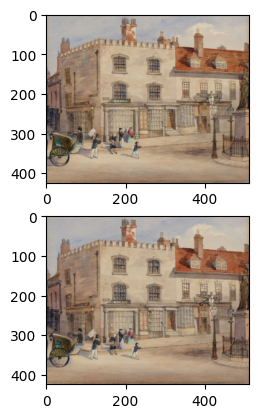

In [8]:
fig, axes = plt.subplots(2)
axes[0].imshow(im_orig)
axes[1].imshow(im_dec)

In [9]:
mse, psnr = mse_psnr(np.array(im_orig), np.array(im_dec))

print(f"{mse=:.3f}, {psnr=:.3f}")

mse=0.002, psnr=26.631


## Flow inversion accuracy check

In [10]:
def process_sample(category: str, sample_name: str):
    file_dir = os.path.join(benchmark_config.root_dir, "DragBench", category)
    sample_path = os.path.join(file_dir, sample_name)
    
    # Load sample
    print(sample_path)
    source_image, prompt, mask, points = load_dragbench_sample(sample_path)
    

    ###### invert_state_from_image

    state = pipe.prepare_state(
        prompt=prompt,
        height=source_image.shape[0],
        width=source_image.shape[1],
        num_inference_steps=pipeline_config.num_inference_steps,
    )
    
    # Encode source image to latent space
    state.latent = np_to_latent(pipe.pipe, source_image)
    state.i = pipeline_config.num_inference_steps  # Start inversion from final step
    
    # Run flow inversion to recover initial noise latent
    state.intermediate_latents = []
    state = pipe.pipe.invert_from_state(state)
    
    # Store inverted latent as initial condition for subsequent editing
    state.initial_latent = state.latent.detach().clone()

    ###### invert_state_from_image - end


    intermediate_1 = state.intermediate_latents


    state = pipe.reset_state(state)
    state = pipe.infer_until(state, drag_config.drag_step)
    state = pipe.infer_until(state, pipeline_config.num_inference_steps)

    intermediate_2 = state.intermediate_latents


    
    # Run drag
    drag_output = run_rf_drag(
        pipe,
        state,
        source_image,
        mask * 255,
        points,
        drag_config,
    )
    
    # Compute evaluation metrics
    #metrics = metrics_evaluator.compute(
    #    base_image=source_image,
    #    dragged_image=drag_output.final_image,
    #    points=points,
    #    prompt=prompt,
    #)
    metrics = {}
        
    # Add to collector
    metrics_collector.add_sample(category, sample_name, metrics)
        
        # Save results
    save_sample_results(
        str(result_dir),
        category,
        sample_name,
        drag_output,
        pipe,
        metrics,
        save_intermediates=benchmark_config.save_intermediates,
    )

    return intermediate_1, intermediate_2


In [11]:
intermediate_1, intermediate_2 = process_sample(category='art_work', sample_name='PJC_2023-09-15-1519-16')

2026-03-11 19:03:36,486 - DEBUG - STREAM b'IHDR' 16 13
2026-03-11 19:03:36,487 - DEBUG - STREAM b'IDAT' 41 65536
2026-03-11 19:03:36,503 - DEBUG - Sample shape is (424, 512, 3), padding to multiple of 32
2026-03-11 19:03:36,504 - DEBUG - Loaded sample: (448, 512, 3), 4 points
2026-03-11 19:03:36,505 - DEBUG - Mask shape (448, 512), mask sum: 10509
2026-03-11 19:03:36,505 - DEBUG - Prompt: An oil painting of buildings
2026-03-11 19:03:36,505 - DEBUG - Preparing state with prompt='An oil painting of buildings', height=448, width=512, num_inference_steps=20


drag_bench_data/DragBench/art_work/PJC_2023-09-15-1519-16


2026-03-11 19:03:38,978 - INFO - Applying drag at step 16 (t=250.0)
/Data/lvt/Flow-DLE/instaflow/drag_utils.py:421: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  optim_steps[-1].loss = float(loss) if not isinstance(loss, float) else loss
2026-03-11 19:03:45,357 - INFO - Drag completed: 80 steps, converged=False
2026-03-11 19:03:45,745 - DEBUG - Saved final image: drag_bench_results/art_work/PJC_2023-09-15-1519-16/dragged_image.png


2026-03-11 19:03:48,565 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2026-03-11 19:03:48,565 - DEBUG - findfont: score(FontEntry(fname='/Data/lvt/Flow-DLE/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 1.335
2026-03-11 19:03:48,566 - DEBUG - findfont: score(FontEntry(fname='/Data/lvt/Flow-DLE/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.05
2026-03-11 19:03:48,566 - DEBUG - findfont: score(FontEntry(fname='/Data/lvt/Flow-DLE/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335


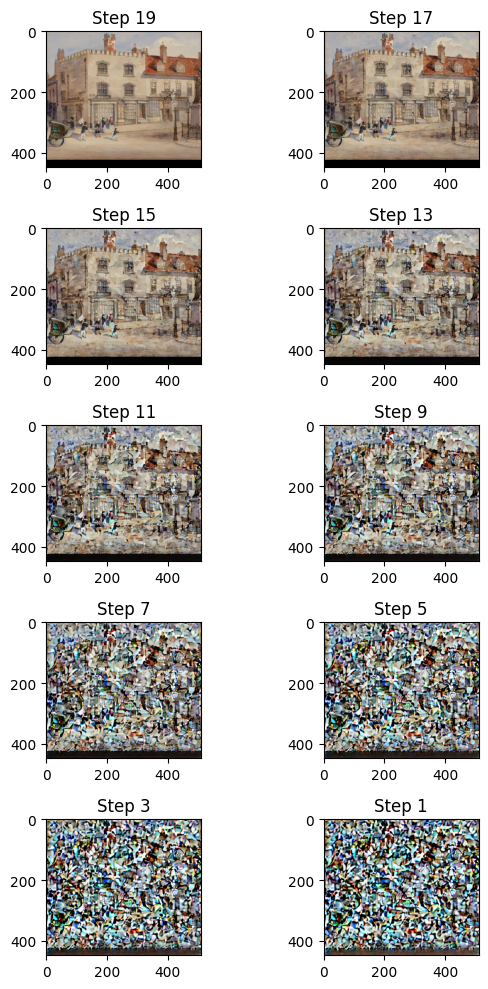

In [12]:
fig, axes = plt.subplots(5, 2)
fig.set_size_inches(6, 10)

for i in range(10):
    ax = axes.flatten()[i]
    info = intermediate_1[2 * i]
    ax.imshow(latent_to_pil(info['latent']))
    ax.set_title(f"Step {info['step']}")
fig.tight_layout()

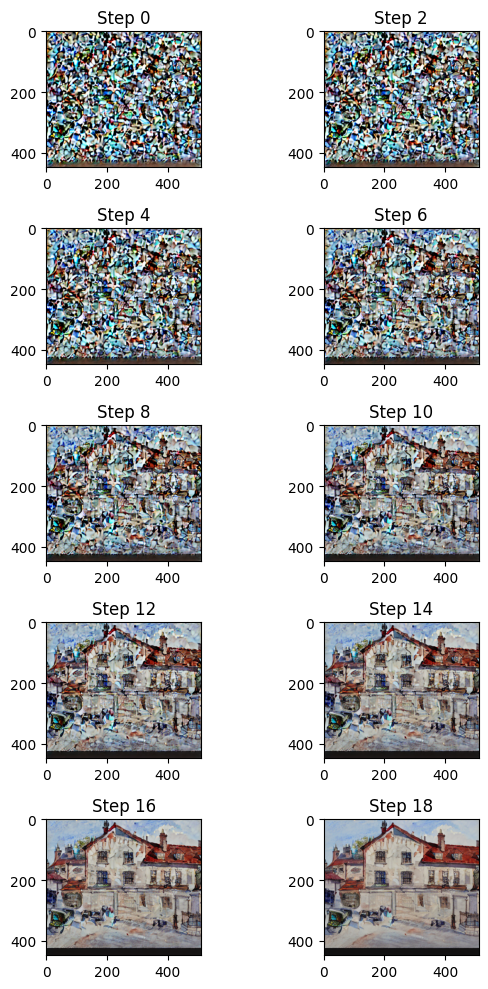

In [13]:
fig, axes = plt.subplots(5, 2)
fig.set_size_inches(6, 10)

for i in range(10):
    ax = axes.flatten()[i]
    info = intermediate_2[2 * i]
    ax.imshow(latent_to_pil(info['latent']))
    ax.set_title(f"Step {info['step']}")
fig.tight_layout()